# Project GEO876 - Wildfire Mapping
Janis Büchel

### Setup and API

Required packages:

In [145]:
# Install Packages:

import pandas as pd
import numpy as np
from datetime import datetime
import geopandas as gpd
import contextily as ctx


To access the API, a map key is required, which can be requested on the website.

In [146]:
#Set map key:
MAP_KEY = "e5b967caf968ec1283cb213a30e9b9d4"

# Set base url:
url = "https://firms.modaps.eosdis.nasa.gov/api/"



### Data Availability


Show which sensors are available on the API:

In [147]:
# Create the correct API-url with the map key and show the list of sensors.
data_availability_url = f"{url}data_availability/csv/{MAP_KEY}/all"
df_data_avialiability = pd.read_csv(data_availability_url)

print("Following sensors are available:")
display(df_data_avialiability)



Following sensors are available:


,data_id,min_date,max_date
0,MODIS_NRT,2026-01-01,2026-05-03
1,MODIS_SP,2000-11-01,2025-12-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-05-03
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-03
5,VIIRS_SNPP_NRT,2026-03-01,2026-05-03
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-05-02
8,GOES_NRT,2022-08-09,2026-05-03
9,BA_MODIS,2000-11-01,2026-02-01


Filter for sensors which recorded wildfired today

In [148]:
# Convert max_date into a date
df_data_avialiability["max_date"] = pd.to_datetime(df_data_avialiability['max_date'])

# Date of today
date_today = pd.Timestamp.now().normalize()
print(date_today)

# Filter for sensors with recordings today
df_available_sens = df_data_avialiability[df_data_avialiability["max_date"] == date_today]
print(df_available_sens)


2026-05-03 00:00:00
            data_id    min_date   max_date
0         MODIS_NRT  2026-01-01 2026-05-03
2  VIIRS_NOAA20_NRT  2026-03-01 2026-05-03
4  VIIRS_NOAA21_NRT  2024-01-17 2026-05-03
5    VIIRS_SNPP_NRT  2026-03-01 2026-05-03
8          GOES_NRT  2022-08-09 2026-05-03


### Data Collection

Collect data for one sensor (MODIS):

In [149]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensor = "MODIS_NRT"
focus_area = "world"
day_range = 5 # max. 5 days

area_url = f"{url}area/csv/{MAP_KEY}/{sensor}/{focus_area}/{day_range}"
df_area = pd.read_csv(area_url)

df_area

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,31.04159,49.40215,302.75,1.51,1.21,2026-04-29,3,Aqua,MODIS,51,6.1NRT,291.98,9.53,N
1,31.04328,49.38674,302.18,1.52,1.22,2026-04-29,3,Aqua,MODIS,47,6.1NRT,291.72,8.90,N
2,31.12479,49.33591,312.84,1.53,1.22,2026-04-29,3,Aqua,MODIS,86,6.1NRT,291.78,21.46,N
3,31.12657,49.32035,328.94,1.54,1.22,2026-04-29,3,Aqua,MODIS,100,6.1NRT,292.87,51.52,N
4,31.13726,49.32189,320.92,1.54,1.22,2026-04-29,3,Aqua,MODIS,100,6.1NRT,293.01,35.16,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27509,49.80062,136.70634,300.72,2.60,1.55,2026-05-03,1024,Terra,MODIS,32,6.1NRT,272.39,36.58,N
27510,32.69451,-103.27326,305.06,1.20,1.10,2026-05-03,1049,Aqua,MODIS,95,6.1URT,281.55,13.39,N
27511,32.69670,-103.28578,315.39,1.20,1.10,2026-05-03,1049,Aqua,MODIS,75,6.1URT,281.62,23.36,N
27512,33.34471,-112.61974,304.27,1.80,1.30,2026-05-03,1050,Aqua,MODIS,95,6.1URT,270.06,22.71,N


Collect data for 3 VIIRS sensors:

In [150]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensors = ["VIIRS_NOAA20_NRT", "VIIRS_NOAA21_NRT", "VIIRS_SNPP_NRT"]
focus_area = "world"
day_range = 1 # max. 5 days

# df for with data from all three sensors:
df_viirs = []

for foc_sensor in sensors:
    area_url = f"{url}area/csv/{MAP_KEY}/{foc_sensor}/{focus_area}/{day_range}"
    df_sens = pd.read_csv(area_url)
    df_sens["sensor_id"] = foc_sensor
    df_viirs.append(df_sens)
    print(f"Data for {foc_sensor} loaded, total {len(df_sens)} rows.")

# Add all three dataframes into one big dataframe
df_viirs = pd.concat(df_viirs, ignore_index=True)
print(f"Total number of rows: {len(df_viirs)}\nFinal df:")
display(df_viirs.head())

Data for VIIRS_NOAA20_NRT loaded, total 10746 rows.
Data for VIIRS_NOAA21_NRT loaded, total 12247 rows.
Data for VIIRS_SNPP_NRT loaded, total 9082 rows.
Total number of rows: 32075
Final df:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,sensor_id
0,-32.20403,28.57669,295.60,0.50,0.66,2026-05-03,1,N20,VIIRS,n,2.0NRT,284.20,0.75,N,VIIRS_NOAA20_NRT
1,-28.67882,32.13124,303.44,0.77,0.77,2026-05-03,1,N20,VIIRS,n,2.0NRT,289.54,1.35,N,VIIRS_NOAA20_NRT
2,-28.54948,31.13534,296.42,0.67,0.74,2026-05-03,1,N20,VIIRS,n,2.0NRT,281.96,0.72,N,VIIRS_NOAA20_NRT
3,-28.35622,23.50766,301.89,0.46,0.47,2026-05-03,1,N20,VIIRS,n,2.0NRT,280.41,2.47,N,VIIRS_NOAA20_NRT
4,-28.20953,23.54935,297.23,0.46,0.47,2026-05-03,1,N20,VIIRS,n,2.0NRT,281.46,1.14,N,VIIRS_NOAA20_NRT


Change acq_date und acq_time to datetime:

In [151]:
df_viirs["acq_time"] = df_viirs["acq_time"].astype(str) # Convert time to string
df_viirs["acq_time"] = df_viirs["acq_time"].str.zfill(4) # Fill with zeros

# Create new column with datetime
df_viirs["acq_datetime"] = pd.to_datetime(
    df_viirs["acq_date"] + " " + df_viirs["acq_time"], 
    format='%Y-%m-%d %H%M'
)
# Print new column
print(df_viirs[["acq_datetime"]].head())

         acq_datetime
0 2026-05-03 00:01:00
1 2026-05-03 00:01:00
2 2026-05-03 00:01:00
3 2026-05-03 00:01:00
4 2026-05-03 00:01:00


Rename columns and display final df

In [152]:
# Select columns
df_viirs_fin = df_viirs[["acq_datetime",
                         "sensor_id",
                         "latitude",
                         "longitude",
                         "bright_ti4",
                         "bright_ti5",
                         "frp",
                         "confidence",
                         "daynight"]].copy()


# Rename columns
df_viirs_fin = df_viirs_fin.rename(columns={
    "acq_datetime": "date/time",
    "latitude": "latitude",
    "longitude": "longitude",
    "bright_ti4": "fire_temperature_k",
    "bright_ti5": "ground_temperature_k",
    "frp": "intensity_mv",
    "sensor_id": "sensor",
    "confidence": "confidence"
})

# Show final dataframe
display(df_viirs_fin.head())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mv,confidence,daynight
0,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-32.20403,28.57669,295.60,284.20,0.75,n,N
1,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.67882,32.13124,303.44,289.54,1.35,n,N
2,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.54948,31.13534,296.42,281.96,0.72,n,N
3,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.35622,23.50766,301.89,280.41,2.47,n,N
4,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.20953,23.54935,297.23,281.46,1.14,n,N


### Create GeoDataFrame

Convert dataframe to geodataframe

In [153]:
gdf_viirs = gpd.GeoDataFrame(
    df_viirs_fin, 
    geometry=gpd.points_from_xy(df_viirs_fin.longitude, df_viirs_fin.latitude),
    crs="EPSG:4326"  # WGS84
)

display(gdf_viirs.head())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mv,confidence,daynight,geometry
0,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-32.20403,28.57669,295.60,284.20,0.75,n,N,POINT (28.57669 -32.20403)
1,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.67882,32.13124,303.44,289.54,1.35,n,N,POINT (32.13124 -28.67882)
2,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.54948,31.13534,296.42,281.96,0.72,n,N,POINT (31.13534 -28.54948)
3,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.35622,23.50766,301.89,280.41,2.47,n,N,POINT (23.50766 -28.35622)
4,2026-05-03 00:01:00,VIIRS_NOAA20_NRT,-28.20953,23.54935,297.23,281.46,1.14,n,N,POINT (23.54935 -28.20953)


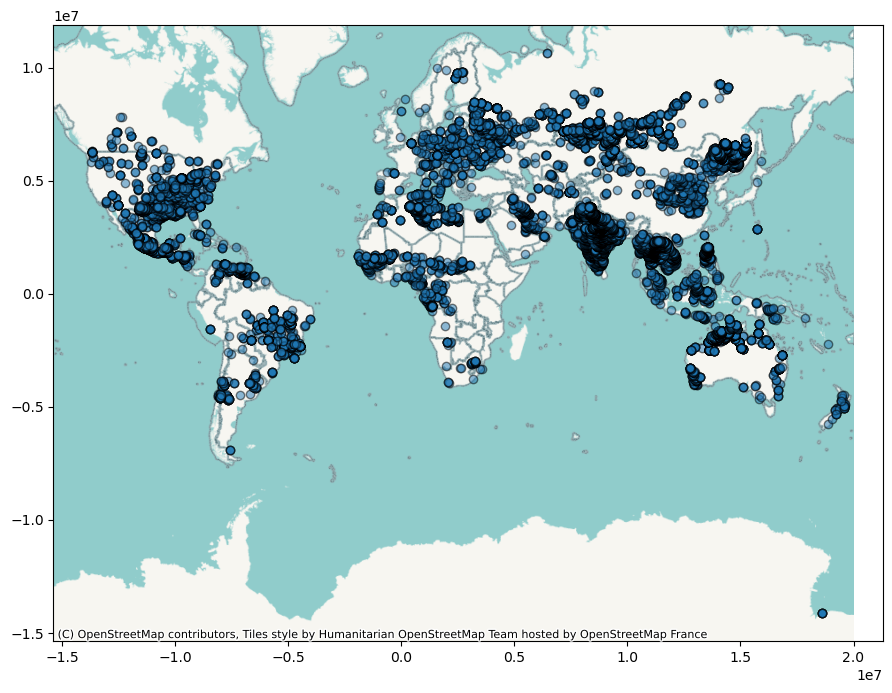

In [154]:
ax = gdf_viirs.to_crs(epsg=3857).plot(figsize=(12, 8), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax)